# Supply Chain Heroes - Predicting Disruptions in Shipments

# Project Requirements
___

## Imports and Other Setup


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import copy
from datetime import datetime as dt
from matplotlib import pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
df = pd.read_csv('supply_chain.csv')
# Copy of DataFrame used in decision tree model - different EDA requirements
supply = df.copy(deep = True)


## Our Question and Background
___
Data source: https://www.kaggle.com/datasets/nudratabbas/global-supply-chain-risk-and-logistics-2024-2026?resource=download

Don't you hate it when you order a new phone and it gets lost in the mail? Imagine how a country's businesses feel when they order a bunch of semiconductors and they don't come in on time! Both globalization has complicated logistics (not the regression kind) and increased the need for on-time deliveries However, thanks to more dangerous weather patterns and ever-rising global conflict, delays and other disruptions have become more frequent. As such, being able to plan for failures is extremely important.

Our research question tries to solve this issue of preparing for delays: *Can you predict whether a shipping disruption is likely to happen given other features such as distance, geopolitical risk, type of product, etc.?* The dataset we chose is a record of shipments of items between different regions of the world. With a selection including clothes, cars, computers, and more, there are all kinds of products that the buyers would hate to lose. The dataset includes context for both the shipment itself (Departure day and place, arrival location, method of travel, product type, carrier reliability, etc.) and global affairs (fuel prices at the time of shipment, geopolitical risk index of shipment region, etc.)

We decided to try tackling various different approaches to prediction, including k-nearest neighbors, logistic regression, and decision trees. Each approach is most thoroughly worked out in its own individual notebook, but our general processes, best models and most critical findings will be documented in this notebook. To see the fully worked-out processes and results for each modeling technique, look through KNN.ipynb, LogisticRegression (2).ipynb, and decision-tree.ipynb. Our findings here are more appropriately connected to our research question and contains the overall conclusions between the three approaches.

# EDA
___



### EDA for kNN Model

Data wrangler was mostly used to decide which features to get rid of or keep. Based on intuition, Shipment ID and Date were removed because it was not believed that these were useful. The other two models actually kept and modified the Date feature, however, this was mostly due to the potential season. Though this is valid, this is similar to the weather feature, so, for this model, and for the sake of difference between the models, Date will remain removed.

The developers of all three models determined that "Lead_Time_Days" required a log transformation independently, which is discussed in another section of this write-up.

When developing the kNN model, there were three features that I felt were important to visualize against our target; origin port, destination port, and product category. These features were chosen due to the geographical and economic information provided.

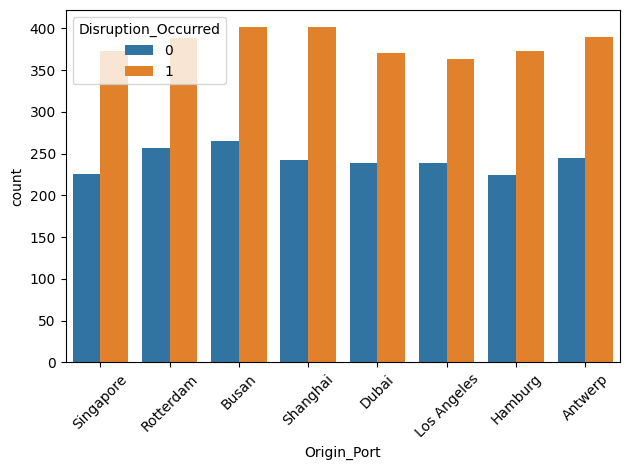

In [5]:
# Countplot of origin port
sns.countplot(data=df, x="Origin_Port", hue="Disruption_Occurred")
plt.xticks(rotation=45) # Just to see the x labels better
plt.tight_layout()
plt.show()

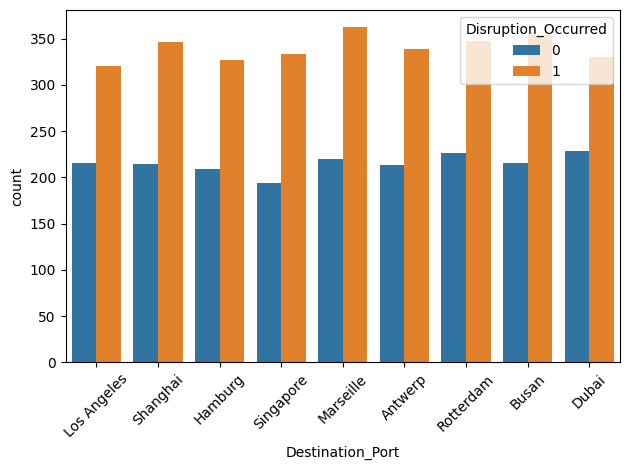

In [6]:
# Countplot of destination port
sns.countplot(data=df, x="Destination_Port", hue="Disruption_Occurred")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

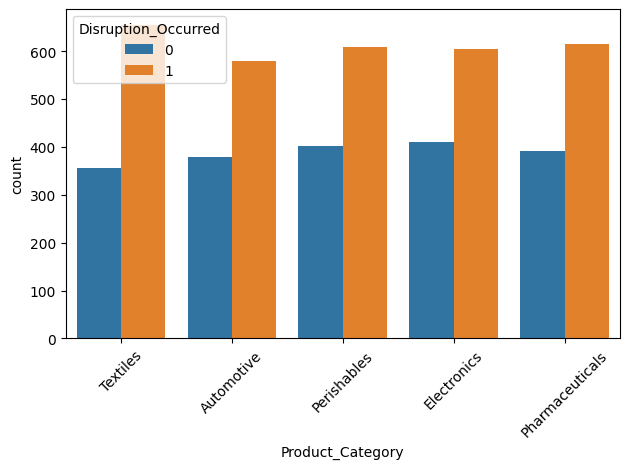

In [7]:
# Countplot of Product Category
sns.countplot(data=df, x="Product_Category", hue="Disruption_Occurred")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

These graphs are reminiscent of the proportion/prevalance of the disruption class (61% positive rate), which suggests that these features in isolation did not offer any significant predicitve power. They may have predictive power in combination with other variables.

The final step for the EDA process for the kNN model was hot encoding, standardizing via MinMaxScaler(), and collapsing features. For this model, it was determined that the distribution of classes within features was evenly divded, so there was no need to collapse anything.

Hot encoding is necessary for this model (and the logistic regression) model because categorical data is not quantitative, which is not useful considering both are mathematical models that require calculations. Categorical information cannot be used to compute the weighted sum of features or to calculate difference. So, the solution is to hot-encode. Hot-encoding gives each category it's own binary column, so the models can utilize this qualtitive data in a useful manner.

In [8]:
CATEGORICALS = ['Origin_Port', 'Destination_Port', 'Transport_Mode',
                'Product_Category', 'Weather_Condition']
df = pd.get_dummies(df, columns=CATEGORICALS, drop_first=True)

### EDA for Logistic Regression Model:
___

Like other models, `Shipment_ID` was removed because it is not a feature. After this, the `Date` column was modified into usable features, such as `Month` and `DayOfWeek`. The code to do this is shown below.

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month']     = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Mon … 6=Sun
df.drop(columns=['Date'], inplace=True)
df.head()

,Shipment_ID,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Origin_Port_Busan,Origin_Port_Dubai,...,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm,Month,DayOfWeek
0,SC-10000,5930.83,197.42,2.43,5.0,0.865,41.39,1,False,False,...,False,False,False,True,False,True,False,False,10,3
1,SC-10001,14285.36,237.24,2.30,7.5,0.592,40.92,1,False,False,...,False,False,False,False,False,False,False,True,4,2
2,SC-10002,11113.91,427.42,1.78,5.6,0.673,11.54,0,False,False,...,False,True,False,False,False,False,True,False,1,4
3,SC-10003,9180.55,170.66,3.20,0.8,0.832,53.13,1,True,False,...,True,False,False,False,False,True,False,False,10,1
4,SC-10004,2762.27,434.96,2.77,1.9,0.741,0.50,1,True,False,...,False,True,False,False,True,False,False,False,9,5


Next, we noticed that the Lead_Time_Days column had a clear right skew, which violates the linearity assumptions logistic regression relies on. To mitigate this, we apply log1p to even the distribution, as shown below.

In [10]:
df['Log_Lead_Time'] = np.log1p(df['Lead_Time_Days'])
df.drop(columns=['Lead_Time_Days'], inplace=True)
df.head()

,Shipment_ID,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Disruption_Occurred,Origin_Port_Busan,Origin_Port_Dubai,Origin_Port_Hamburg,...,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm,Month,DayOfWeek,Log_Lead_Time
0,SC-10000,5930.83,197.42,2.43,5.0,0.865,1,False,False,False,...,False,False,True,False,True,False,False,10,3,3.746912
1,SC-10001,14285.36,237.24,2.30,7.5,0.592,1,False,False,False,...,False,False,False,False,False,False,True,4,2,3.735763
2,SC-10002,11113.91,427.42,1.78,5.6,0.673,0,False,False,False,...,True,False,False,False,False,True,False,1,4,2.528924
3,SC-10003,9180.55,170.66,3.20,0.8,0.832,1,True,False,False,...,False,False,False,False,True,False,False,10,1,3.991389
4,SC-10004,2762.27,434.96,2.77,1.9,0.741,1,True,False,False,...,True,False,False,True,False,False,False,9,5,0.405465


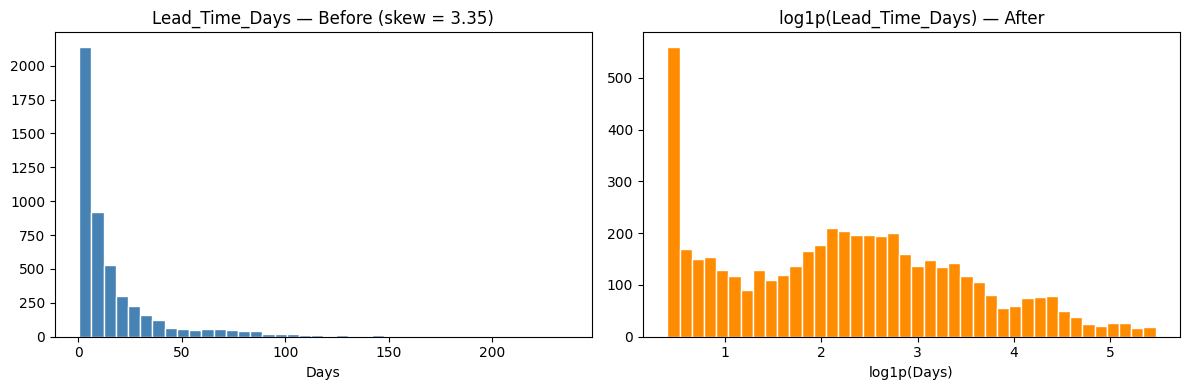

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before_data = np.expm1(df['Log_Lead_Time'])
axes[0].hist(before_data, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Lead_Time_Days — Before (skew = 3.35)')
axes[0].set_xlabel('Days')

axes[1].hist(df['Log_Lead_Time'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('log1p(Lead_Time_Days) — After')
axes[1].set_xlabel('log1p(Days)')

plt.tight_layout()
plt.show()

### EDA for Decision tree
___

Decision trees need less preprocessing than other models, since binary splits are made on a single column and do not consider data scale. The main data analysis problem that decision tree models grapple with is categorical columns having too many options to choose from.

I noticed this issue was particularly apparent in this data set, with multiple categories with 8 options. I tried to see if I was able to condense any of them into a larger "other" category. Unforunately, the categorical columns all had very balanced values that were unable to be condensed effectively, as seen in the graph below of one such column. I figured that this would be a more diffcult model to work with because of this issue, but I gave it a try regardless.

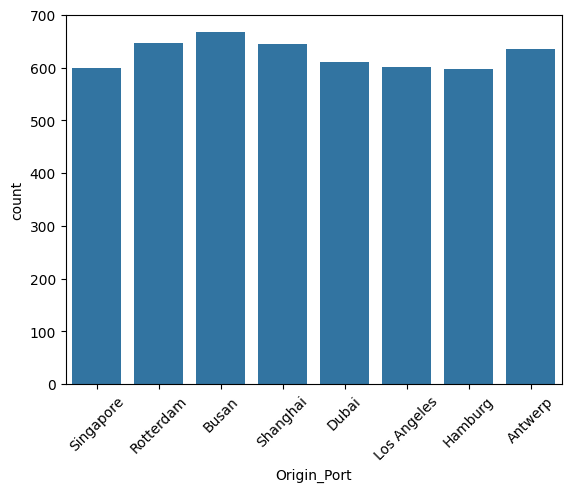

In [12]:
g = sns.countplot(supply, x='Origin_Port')
plt.xticks(rotation=45)
plt.show()

One other issue that I ran into was the date column. Binary splits on a timeline seemed like they would be a feature that would not only be easy to overfit on because the model would narrow down to very specific days that more problems occurred on, over many problematic days.

My transformation was making the date column into a 4-category column based on astronomical season, since seasonality of the shipment could suggest higher likelihood of problematic weather conditions. I did this with a lambda function over the date column shown below.

In [13]:
def season(date: str):
    dto = dt.strptime(date, '%Y-%m-%d')
    date = (dto.month, dto.day)
    # Tuple comparison lets you compare month first,  then
    if date >= (3, 20) and date < (6, 21):
        return 'Spring'
    elif date >= (6, 21) and date < (9, 22):
        return 'Summer'
    elif date >= (9, 22) and date < (12, 20):
        return 'Fall'
    else:
        return 'Winter'

supply['Season'] = supply['Date'].apply(season)
supply_season = supply.drop(columns=['Date','Shipment_ID'])

Shipment ID was dropped, like the other models, since it is an identifier and not a feature. I used supply_season as the dataset for my model going forward.

# Methods
___

### Methods for kNN model

Because our research question is a binary classification model, we figured that the simplest, least comples algorithm would be a kNN model. If successful, there would be no need for a more sophisticated model, which is significant when considering time and resources. Additionally kNN is a good baseline; it's simple enough to compare to a more complex model. If a more complex model doesn't significantly improve in evaluation metrics, we know that kNN will suffice.

Because kNN is a distance based model, all numeric features were scaled via MinMaxScaler(). Categorical features were included, which introduced mathemtical errors that will be discussed later. For now, know that the categorical features were hot-encoded and then scaled via MinMaxScaler() so that all features would be on the same scale and could be appropriately used in the kNN model. Scaling and OHE was used via pipeline to prevent any data leakage between the testing and training data:

In [14]:
# NUMERIC = numeric columns, CATS = categorical columns. Look at kNN file for functional code.

# preprocessor = ColumnTransformer(transformers=[
    # ("num", MinMaxScaler(), NUMERIC),
    # ("cat", Pipeline(steps=[
        # ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        # ("scale", MinMaxScaler())
    # ]), CATS)
# ])

# pipeline = Pipeline(steps=[
    # ("preprocessor", preprocessor),
    # ("model", KNeighborsClassifier(n_neighbors=5))
# ])

The initial model displayed higher recall for disruptions rather than non-disruptions, which is consistent with the 61% positive prevalence. Because kNN does not have a parameter like class_weight, we thought of utilizing the weight parameter. We set weight=distance, which weights each neighbor's vote by inverse distance (closer neighbors have more influence) rather than treating all k neighbors equally. However, because 61/39 is a mild imbalance, we predicted that this would have little to no influence. Furthermore, due to weak univariate correlations between certain features and the target, distance in feature space is not as meaningful, undermining the core reason for utilizing the weight parameter. In the end, the weight parameter did not change any evaluation metrics (will be discussed in evaluation section).

Next, we looked at tuning the hyper parameter, k. All k values from 1-20 were considered (while using 5-fold cross-validation for robust hyper-parameter tuning), and after plotting, we decided that k=5 was the best due to the loss of significant change in AUC after k=5. Look at the kNN file to view the plot (the code would be too much for this jupyter notebook).

Lastly, we decided introduce PCA after viewing a correlation plot with all the features and our target variable, disruptions. OrdinalEncoder() was used to keep categorical features in one column. This function still provided a sense of signal, if any was there, but the magnitude of the signal would not be mathematically reliable. After noticing that some features had a generally weak correlation with disruptios, we used PCA for dimensionality reduction. 95% of the variance was kept, and the sparse_matrix=False argument from the pre-processor provided the matrix necessary for the matrix calculations. Throughout this process, there was no signifcant improvement in evaluation metrics, which will be discussed in the evaluation section.

In [15]:
# pipeline_pca = Pipeline(steps=[
    # ("preprocessor", preprocessor),
    # ("pca", PCA(n_components=0.95, svd_solver="full")),
    # ("model", KNeighborsClassifier(n_neighbors=5))
# ])

# pipeline_pca.fit(X_train, y_train)
# print(classification_report(y_test, pipeline_pca.predict(X_test)))

# AUC_pca = roc_auc_score(y_test, pipeline_pca.predict_proba(X_test)[:, 1])
# print(f"AUC: {AUC_pca:.4f}")

As mentioned earlier, it is important to discuss why this model mathematically does not work. Notice the MinMaxScaler() on the categorical values in the pre-processor. This is a "band-aid" fix to a huge wound in the model. Fundamentally, categorical values do not work with kNN models even after OHE because Euclidean distance treats the binary columns as continuous magnitudes. To have a mathematically correct mode, the categorical columns would have to be deleted, which would be a huge loss in data collection and would not produce a proper result.

It was concluded that kNN was not the proper model for this dataset due to the weak univariate correlations that undermine the meaning of distance in the feature space and the mathematically incorrect interpretation of the categorical features.

### Methods for Logistic Regression Model:
___

We used logistic regression because the problem is straightforward: either a shipment gets disrupted or it doesn't. It's also one of the more interpretable models out there, meaning we can look at the coefficients at the end and actually understand what drove the predictions.

The one thing we were careful about was scaling. Some features are measured in kilometers, others as index scores. Without standardizing them first, the larger-scale variables would unfairly dominate the model. But you have to scale using training data only, otherwise you're letting the model peek at the test set before evaluation. We handled this by wrapping everything in a pipeline so it happens automatically in the right order:


In [16]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

The first model we ran showed the model was better at catching disruptions than non-disruptions, which isn't surprising. Disruptions make up 61% of the data, so the model just sees more of them during training. We fixed this with one small adjustment that tells the model to treat both classes as equally important regardless of how often they appear:

In [17]:
LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

We also tested whether combining features could improve predictions. Specifically, whether geopolitical risk or fuel prices matter more on longer routes. We added two interaction terms and refitted:

In [18]:
X = df.drop(columns=['Disruption_Occurred', 'Shipment_ID'])
y = df['Disruption_Occurred']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train['Risk_x_Distance'] = X_train['Geopolitical_Risk_Score'] * X_train['Distance_km']
X_train['Fuel_x_Distance'] = X_train['Fuel_Price_Index'] * X_train['Distance_km']

They didn't help, so we dropped them and kept things simple. To make sure our results weren't just luck from one particular train/test split, we ran 5-fold stratified cross-validation, training on 4 folds and evaluating on the fifth, rotating through all combinations:

In [19]:
pipeline_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(pipeline_balanced, X_train, y_train, cv=cv, scoring='roc_auc')
cv_f1  = cross_val_score(pipeline_balanced, X_train, y_train, cv=cv, scoring='f1')




Finally, we applied isotonic calibration on top of the model to make sure its predicted probabilities are trustworthy. If it says a shipment has a 70% chance of disruption, that should reflect something close to the true observed rate rather than just a raw model score:

In [20]:
pipeline_calibrated = CalibratedClassifierCV(pipeline_balanced, method='isotonic', cv=5)
pipeline_calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit 

We also examined whether the default 0.5 decision threshold was the right cutoff. Lowering it catches more real disruptions but generates more false alarms; raising it does the opposite. The right choice ultimately depends on whether missing a disruption or acting on a false alarm is more costly in practice.

### Methods for Decision Tree Model
___

*This section contains code snippets from decision-tree.ipynb, where my full process can be found. This section more directly relates my model choices to our research question.*

This dataset is specifically noted to have several nonlinear relationships in the variables towards prediction of disruptions. I thought that decision trees might be a better modeling technique because decision trees are optimized for nonlinear connections by using binary splits rather than linear combination of features. However, unchecked decision trees naturally tend to overfit the training data. As such, I decided to take an iterative approach to developing these models, starting with an intentionally poorly designed baseline and improving hyperparameter selection with the baseline as a comparison.

Train-test split code for my model is below:

In [21]:
print(supply_season.head())

  Origin_Port Destination_Port Transport_Mode Product_Category  Distance_km  \
0   Singapore      Los Angeles           Rail         Textiles      5930.83   
1   Singapore         Shanghai           Rail       Automotive     14285.36   
2   Rotterdam      Los Angeles           Rail      Perishables     11113.91   
3       Busan          Hamburg           Rail      Electronics      9180.55   
4       Busan        Singapore            Air      Perishables      2762.27   

   Weight_MT  Fuel_Price_Index  Geopolitical_Risk_Score Weather_Condition  \
0     197.42              2.43                      5.0         Hurricane   
1     237.24              2.30                      7.5             Storm   
2     427.42              1.78                      5.6              Rain   
3     170.66              3.20                      0.8         Hurricane   
4     434.96              2.77                      1.9               Fog   

   Carrier_Reliability_Score  Lead_Time_Days  Disruption_Occur

In [22]:
X_supply = supply_season.drop(columns='Disruption_Occurred')
y_supply = supply_season[['Disruption_Occurred']]

In [23]:
Xtr, Xsp, ytr, ysp = train_test_split(X_supply, y_supply, train_size=0.7, random_state=809)
Xtu, Xte, ytu, yte = train_test_split(Xsp, ysp, train_size=0.5, random_state=809)

Decision trees do not need as heavy of preprocessing as other models. The only preprocessing for each of my models was to ordinally encode the categorical columns so that they became numeric-based splits:

In [24]:
cat_cols = list(X_supply.select_dtypes(include='object').columns)
# Here in case I need it - not necessary with decision tree models
#num_cols = list(supply.select_dtypes(include='number').columns)

preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(), cat_cols),
], remainder='passthrough')

/tmp/ipykernel_4734/604187116.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = list(X_supply.select_dtypes(include='object').columns)


My first model was completely without parameters to establish a baseline on where to improve the model from:

In [25]:
dt_pipe_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=809))
])

The first model overfit heavily to perfectly classify the training data, but the testing data had poor results. The following models used different techniques to help improve generalizability of this one to the testing data.

My second model used grid-search cross-validation to seek out an optimal combination of max depth, minimum terminal node samples, and minimum impurity decrease to improve generalizability from the first tree. Why I chose each is shown below:
- Max depth: The first tree had as many layers as necessary, and it's barely readable. Most splits beyond a small correction of just a few samples occur between 8-10 levels down, but the tree went way deeper than that. I used 6, 8, and 10 to account for both extremes.
- Minimum leaf samples: This tree had tons of splits at lower layers that split on... 5 values or less. Removing those would make it easier to fit test data. I chose 20, 30, 40, and 50 because those numbers came up often some earlier, non-terminal nodes and I wanted to allow flexibility in searching with the depth limit as well.
- Minimum impurity decrease: Many of the nodes in the overfit tree didn't decrease the impurity all that much. I left 0 in because I was unsure if this restriction would help, and tried values at the low end to make sure splits could still be made.

In [26]:
params = {
    "classifier__max_depth": (6, 8, 10),
    "classifier__min_samples_leaf": (20, 30, 40, 50),
    "classifier__min_impurity_decrease": (0, .1, .2, .3)
}

scoring = ['roc_auc','recall','balanced_accuracy']

gs_obj = GridSearchCV(estimator=dt_pipe_1,
                            param_grid=params, scoring=scoring, n_jobs=-1,
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=809),
                            refit='roc_auc')

gs_model = gs_obj.fit(Xtr, ytr)
best = gs_obj.best_estimator_

# To access the underlying DecisionTreeClassifier from the pipeline:
best_clf = best.named_steps['classifier']
dt_pipe_2 = Pipeline(steps=(
    ('preprocessor', preprocessor),
    ('classifier', best_clf)
))

The second model had suboptimal results for negative-class metrics. It performed far better at classifying shipments with delays than shipments that were on time. My third model has the same parameters as the grid-search optimized model, but has balanced class weights to try and improve its safe-shipment metric performance:

In [27]:
best_balanced = copy.deepcopy(best_clf)
best_balanced.class_weight = 'balanced'

dt_pipe_3 = Pipeline(steps=(
    ('preprocessor', preprocessor),
    ('classifier', best_balanced)
))

My fourth model took a different approach than grid-search to started over from the overfit tree, but used minimum cost-complexity pruning (CCP) to cut off an optimal number of leaves to best fit the testing data instead of grid search for a set of parameters that seemed to be useful. CCP progressively cuts more splits from the ends of the tree made on the training data in order of least impactful splits first, and you choose the tree with the best testing results at the end.

In [28]:
path_disrupt = dt_pipe_1.named_steps['classifier'].cost_complexity_pruning_path(
    dt_pipe_1.named_steps['preprocessor'].fit_transform(Xtr), ytr
)

# The path_disrupt line above returns two values: Alpha parameter thresholds where leaves
# are cut (ccp_alphas) and the sum of weighted impurities in the tree's leaves
# at those alpha levels (impurities)
ccp_alphas, impurities = path_disrupt.ccp_alphas, path_disrupt.impurities
clfs = []
for ccp_alpha in ccp_alphas:
    clf_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=809, ccp_alpha=ccp_alpha))
    ])
    clf_pipe.fit(Xtr, ytr)
    clfs.append(clf_pipe)

#The last model is a single-node tree, which is trivial, so we remove it.
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

train_scores = [clf.score(Xtr, ytr) for clf in clfs]
test_scores = [clf.score(Xtu, ytu) for clf in clfs]
best_index = np.argmax(test_scores)
# Print out the accuracy for that model
print(test_scores[best_index])
# This is the pipeline with the CCP alpha optimized for the testing data
# In an ideal scenario, this is the model with the best generalization
best_alpha_pipe = clfs[best_index]


0.728


My fifth model took the ensemble method approach to mitigate overfitting by using a random forest, which is a majority vote by many trees with fewer features to choose from. Despite having no parameters, it far outperformed the unfit tree, its metrics even on par with the grid-search single tree:

In [29]:
rf_pipe_1 = Pipeline(steps=(
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=809))
))

My final model used grid search to try to optimize the random forest's subtrees:

In [30]:
scoring_rf = ['roc_auc','recall','balanced_accuracy']

params_rf = {
    "classifier__max_depth": (6, 8, 10),
    "classifier__min_samples_leaf": (20, 30, 40, 50),
    "classifier__min_impurity_decrease": (0, .1, .2, .3)
}

gs_obj_rf = GridSearchCV(estimator=rf_pipe_1,
                            param_grid=params_rf, scoring=scoring_rf, n_jobs=-1,
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=809),
                            refit='roc_auc')

gs_model_rf = gs_obj_rf.fit(Xtr, ytr)

# I more explicitly extracted the parameters from the best-performing
# classifier and put them in a new RandomForestClassifier object this time
best_rf = gs_obj_rf.best_estimator_
best_clf_rf = best_rf.named_steps['classifier']
best_depth_rf = best_clf_rf.max_depth
best_leaf_samples_rf = best_clf_rf.min_samples_leaf
best_impurity_dec_rf = best_clf_rf.min_impurity_decrease

rf_pipe_2 = Pipeline(steps=(
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth=best_depth_rf,
                                          min_samples_leaf=best_leaf_samples_rf,
                                          min_impurity_decrease=best_impurity_dec_rf,
                                          random_state=809))
))


/workspaces/DS3021-final/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/DS3021-final/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/DS3021-final/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/workspaces/DS3021-final/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d a

# Evaluation
___

### Evaluation for kNN

Despite the methods used, the evaluation metrics from the baseline model throug the entire improvement process did not change. Here is an example of the classification report:

precision    recall  f1-score   support

           0       0.58      0.52      0.55       387
           1       0.72      0.77      0.74       613

    accuracy                           0.67      1000
   macro avg       0.65      0.64      0.64      1000
weighted avg       0.66      0.67      0.67      1000

AUC: 0.7212

For the logistic regression and kNN models, AUC and F1 score were prioritized because AUC captures the model's classification ability all decision thresholds, while F1 balances precision and recall into a single metric that we believe reflects performance on both classes rather than just the majority. When AUC is compared with the logistic regression model, it is clear there is a fundamental mismatch between the kNN algorithm and this dataset. Despite this conclusion, here is an example of the confusion matrix to compare with other models (full code can be found in kNN model file)

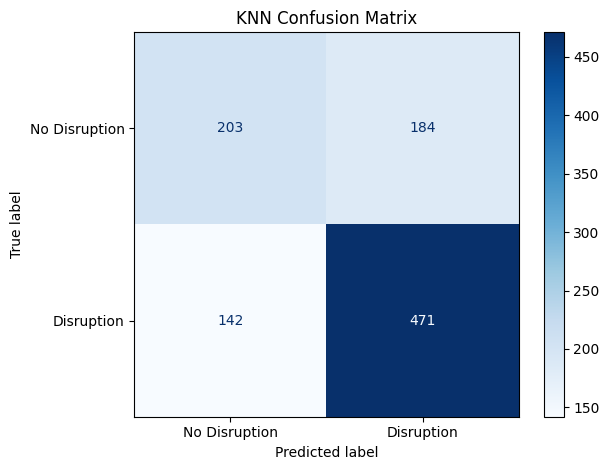

In [31]:
cm3 = np.array([[203, 184],
                [142, 471]])

disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=["No Disruption", "Disruption"])
disp3.plot(cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

### Evaluation for Logistic Regression Model
___

              precision    recall  f1-score   support

           0       0.66      0.64      0.65       387
           1       0.78      0.79      0.79       613

    accuracy                           0.73      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.73      0.73      0.73      1000

AUC-ROC: 0.827


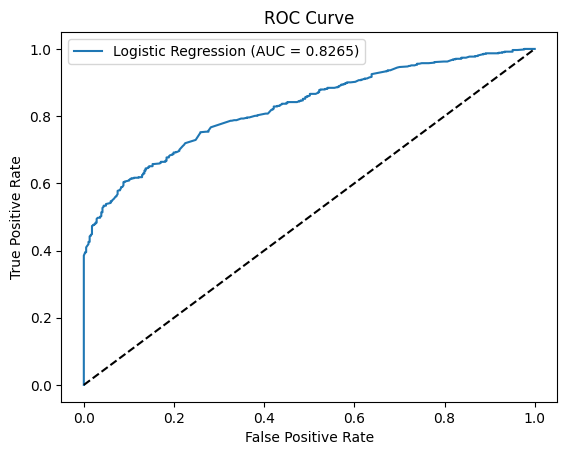

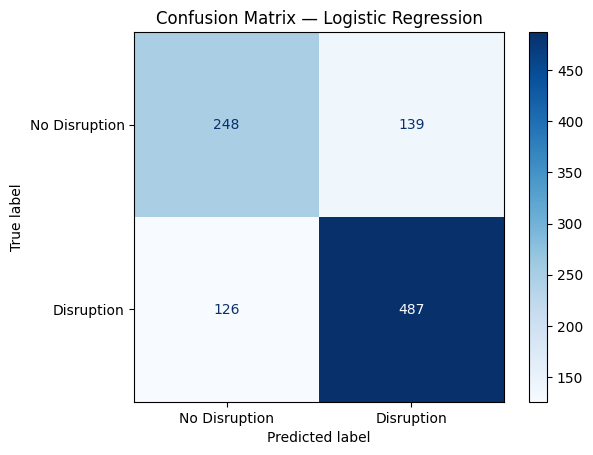

In [32]:
# Drop interaction terms if they still exist
X_train.drop(columns=['Risk_x_Distance', 'Fuel_x_Distance'], inplace=True, errors='ignore')
X_test.drop(columns=['Risk_x_Distance', 'Fuel_x_Distance'], inplace=True, errors='ignore')

# Refit
pipeline_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
pipeline_calibrated = CalibratedClassifierCV(pipeline_balanced, method='isotonic', cv=5)
pipeline_calibrated.fit(X_train, y_train)

# Evaluate
print(classification_report(y_test, pipeline_calibrated.predict(X_test)))
print(f"AUC-ROC: {roc_auc_score(y_test, pipeline_calibrated.predict_proba(X_test)[:,1]):.3f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, pipeline_calibrated.predict_proba(X_test)[:, 1])
auc = roc_auc_score(y_test, pipeline_calibrated.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, pipeline_calibrated.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['No Disruption', 'Disruption']).plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

The model finished with an AUC of 0.83, meaning it correctly distinguishes disrupted from non-disrupted shipments about 83% of the time, well above random chance. Overall accuracy came in at 73%.

The confusion matrix shows the tradeoff in practice: the model is better at catching actual disruptions (high recall on class 1) than it is at clearing shipments that won't be disrupted. This is a reasonable outcome for this kind of problem, in supply chain management, missing a real disruption is generally more costly than a false alarm, so erring on the side of caution makes sense.

The ROC curve confirms the model is meaningfully better than guessing across all possible thresholds, with a smooth curve well above the diagonal baseline. The fact that cross-validation produced nearly identical results (0.826 ± 0.014) tells us this performance is stable and not just the result of a lucky train/test split.

### Evaluation for Decision Tree Model
___

I got different metrics for each model as I went so I could tune the hyperparameters in future models. I paid special attention to positive class recall (% of true positives that were actually uncovered) and ROC-AUC (performance of model at different classification thresholds). The former is important because our goal was to find as many actual delays as possible (pos. recall is true pos. detection rate) so that buyers could incorporate time for delays in shipping in their schedule, and the latter was important because ROC-AUC accounts for class imbalances in the dataset (more shipments were delayed than safe) as well as being useful as a robust metric that compares the other modeling techniques we used, like kNN and logistic regression, to this one.

The helper function below fit a pipeline to training data and returned its training accuracy as well as various testing metrics, which are the more important comparison points between models. It also created a graph with a confusion matrix for easy viewing of where the model struggles without needing to interpret precision and recall. I used it with the tuning data in place of the testing data while I was developing the models:

In [33]:
def model_fit_metrics(pipe: Pipeline, x, y, xt, yt, display_labels=['Safe', 'Disrupted']):
    """Fits a binary classification pipeline, then prints its training and tuning accuracy,
    its classification report, and a confusion matrix display given training and testing X and Y.

    Args:
        pipe (sklearn.pipeline.Pipeline): A pipeline that has the fit() function.
        x (pd.DataFrame): The training features.
        y (pd.DataFrame): The training labels.
        xt (pd.DataFrame): The tuning features.
        yt (pd.DataFrame): The tuning labels.
        display_labels (list): The negative and positive class labels.
    Returns:
        pipe (sklearn.pipeline.Pipeline): The fitted pipeline.
        results (pd.DataFrame): A DataFrame with the columns: target, pred, prob_safe, prob_disrupted
    """
    pipe.fit(x, y)
    print("Training score:", pipe.score(x, y))
    print("Tuning score:", pipe.score(xt, yt))
    # Get better metrics than accuracy for tuning
    dt_pred = pipe.predict(xt)
    dt_prob = pipe.predict_proba(xt)

    # Bundle everything into a tidy DataFrame
    results = pd.DataFrame({
        'target': yt.squeeze(),
        'pred': dt_pred,
        'prob_safe': dt_prob[:, 0], # first column
        'prob_disrupted': dt_prob[:, 1] # second column
    })

    from sklearn.metrics import (
        confusion_matrix, ConfusionMatrixDisplay
    )
    cm = confusion_matrix(results['target'], results['pred'])
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    display.plot(cmap='Greens')
    print(classification_report(results['target'], results['pred'], target_names=display_labels))
    return pipe, results

My other metrics helper was this code from one of the labs that cleanly displayed the ROC curve and AUC from it:

In [34]:
def labeled_roc_auc_graph(results: pd.DataFrame, graphname, yhat_prob_colname='prob_disrupted',
                          y_colname='target'):
    y_proba = results[yhat_prob_colname]
    ytarget = results[y_colname]
    fpr, tpr, thresholds = roc_curve(ytarget, y_proba)
    auc = roc_auc_score(ytarget, y_proba)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'{graphname} (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{graphname} ROC Curve')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    print(f"{graphname} ROC-AUC: {auc:.4f}")
    return auc

After tuning all of the models appropriately, I fed each model the held-out testing data. Out of all of the tested models, the most consistently high-performing tree was the tree with minimum cost-complexity pruning. Its metrics on the *testing data* (not the tuning data, despite being labeled as such) can be seen below:

Training score: 0.738
Tuning score: 0.7213333333333334
              precision    recall  f1-score   support

        Safe       0.65      0.57      0.61       286
   Disrupted       0.76      0.81      0.78       464

    accuracy                           0.72       750
   macro avg       0.70      0.69      0.70       750
weighted avg       0.72      0.72      0.72       750



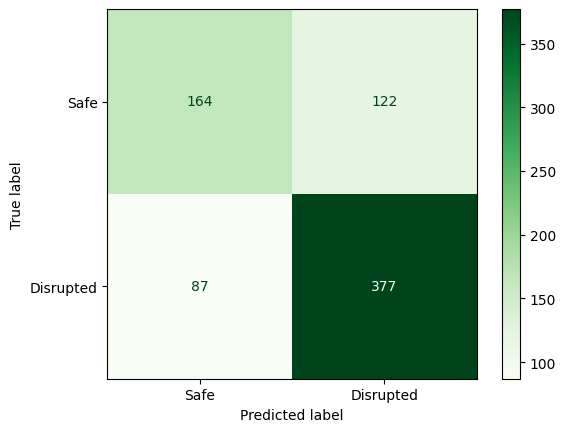

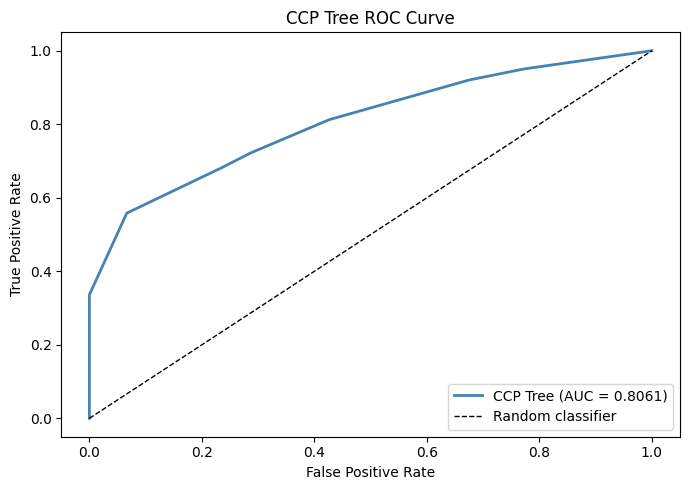

CCP Tree ROC-AUC: 0.8061


0.8060909995177237

In [35]:
optimal_model, results = model_fit_metrics(best_alpha_pipe, Xtr, ytr, Xte, yte, display_labels=['Safe', 'Disrupted'])
labeled_roc_auc_graph(results, "CCP Tree")

This model is much more effective at its positive class metrics, which makes sense given its 61% prevalence. In context, this means it is better at finding shipments that have disruptions than shipments that arrive on time. However, misclassifying a shipment that arrives on time and making unnecessary preparations for it to come in late is less costly than misclassifying a shipment that is needed on time that comes late and needing to re-organize after that delay, so this shortcoming is more acceptable in this case. Its positive recall is very strong, with 81% detection rate. In addition, it is a relatively robust model, at an 80.6% ROC-AUC level. However, it is still only 72% accurate on data it has not seen before. Compared with the results of the other models, it looks like this problem is quite difficult to classify with a strong degree of certainty given these features.

# Conclusions
___

Going back to our original question on whether we can predict if a shipping disruption is likely to occur given features like distance, geopolitical risk, product type, and more, the answer is a cautious yes, and logistic regression is the model we'd recommend.

Its ROC-AUC of 0.83, stable at 0.826 plus or minus 0.014 across five cross-validation folds, was the strongest of the three approaches. More importantly, it produces calibrated probabilities you can trust and interpretable coefficients for each feature that demonstrate the importance of each feature in how likely a disruption is to occur. A logistics manager can look at the model, see that shipments through high geopolitical risk regions are flagged at a meaningfully higher rate, understand why, and build a policy around it. That kind of transparency matters enormously when you are trying to get an organization to actually act on a model's output.

It is worth being upfront about the limitations though. One-hot encoding the categorical columns created a high-dimensional feature space, and that hurts both logistic regression and kNN. When you have many weakly informative columns, the signal gets diluted, and for kNN specifically the concept of nearest neighbor starts to lose meaning entirely since every point looks roughly equidistant from every other in high-dimensional spaces. Logistic regression handles this better than kNN but still assumes a linear decision boundary, which may not be appropriate given the nonlinear relationships in this data. The decision tree models are actually better suited to that problem since they evaluate one feature at a time and can naturally ignore irrelevant ones. The CCP-pruned tree hit 0.806 AUC and the random forest was competitive as well, and may be an effective alternative solution. However, we are recommending logistic regression on interpretability and practical grounds due to its stronger overall metrics and ease of explanation to relevant stakeholders in this scenario.

The most realistic application is using the model's probability scores to flag high-risk shipments before they leave. A logistics team could set a threshold where any shipment above a certain disruption probability gets flagged for human review, triggering decisions around backup carriers, adjusted timelines, or pre-positioned inventory. Of the available features, geopolitical risk score is probably the most actionable lever for real policy. Weather is notoriously hard to predict even for professional meteorologists, so building disruption policy around it is unreliable since you often will not know far enough in advance to meaningfully respond. Geopolitical risk changes more slowly and lets organizations make longer-term structural decisions, so they are probably a better parameter to rely on, even if there is a weaker correlation with disruption than weather features.

Finally, an AUC of 0.83 and 73% accuracy are decent but not strong enough to rely on blindly. The features here are broad proxies, and more granular data like carrier-level reliability history or port congestion metrics would likely push performance higher. The dataset also covers one time window and one region, so generalization elsewhere is an open question. The model is a useful starting point for risk flagging, not a replacement for human judgment.

# Team Contribution
___
Ryan Cohen developed the logistic regression models and wrote the conclusion section of this write-up.  
Paco Herrera developed the kNN models and improved the formatting of this notebook to be more consistent and presentable.  
Cameron Berryman developed the decision tree models, wrote the intro section of this write-up, and set up the GitHub repository for this project.